# 1. 线性回归的从零开始实现

我们将从零开始实现整个方法，包括数据流水线、模型、损失函数和小批量随机梯度下降优化器

In [56]:
import torch
from pyexpat import features
%matplotlib inline
import random
from d2l import torch as d2l

In [57]:
def synthetic_data(w,b,num_examples):
    """生成 y = Xw + b  + 噪声   """
    X = torch.normal(0,1,(num_examples,len(w)))
    y = torch.matmul(X,w) + b
    y += torch.normal(0,0.01,y.shape)
    return X, y.reshape((-1,1))

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features, labels = synthetic_data(true_w,true_b,1000)

In [58]:
print('features:',features[0],'\nlabel:', labels[0])

features: tensor([ 0.2158, -0.5490]) 
label: tensor([6.5042])


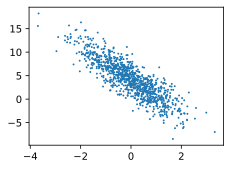

In [59]:
d2l.set_figsize()  # 设置绘图窗口大小

d2l.plt.scatter(
    features[:,(1)].detach().numpy(),  # 取features(X)的第2列特征作为x轴；detach()取消梯度追踪；numpy()转换为numpy数组方便绘图
    labels.detach().numpy(),           # labels(y)作为y轴数据；detach()取消梯度追踪；numpy()转换为numpy数组
    1                                  # 设置散点大小
)

定义一个data_iter函数，该函数接收批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量

In [60]:
def data_iter(batch_size ,features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(indices[i:min(i+
                                                   batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

batch_size = 10
for X, y in data_iter(batch_size,features,labels):
    print(X,'\n', y)
    break

tensor([[-0.5143, -0.9279],
        [-0.2741, -0.4299],
        [-1.3891,  1.1972],
        [-1.1655,  0.6491],
        [ 1.0953,  0.7267],
        [-0.5860, -1.2928],
        [-0.8827,  0.6594],
        [ 0.8005,  0.7195],
        [-0.6896,  1.2784],
        [ 1.3111, -1.3036]]) 
 tensor([[ 6.3253],
        [ 5.1412],
        [-2.6509],
        [-0.3282],
        [ 3.9131],
        [ 7.4401],
        [ 0.1869],
        [ 3.3602],
        [-1.5501],
        [11.2444]])


In [61]:
# 定义初始化模型参数
w = torch.normal(0,0.01,size=(2,1),requires_grad=True)
b = torch.zeros(1,requires_grad=True)

In [62]:
# 定义模型
def linreg(X,w,b):
    # 线性回归模型
    return torch.matmul(X,w) + b

In [63]:
# 定义损失函数
def squared_loss(y_hat,y):
    # 均方损失
     return (y_hat - y.reshape(y_hat.shape)) ** 2 /2


In [64]:
# 定义优化算法
def sgd(params, lr, batch_size):
    #小批量随机梯度下降
    with torch.no_grad():
        for param in params:
            param -= lr*param.grad / batch_size
            param.grad.zero_()

In [65]:
# 训练过程
lr = 0.03
num_epochs = 9
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size, features, labels):
        l = loss(net(X,w,b),y)

        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_l = loss(net(features,w, b),labels)
        print(f'epoch{epoch + 1},loss {float(train_l.mean()):f}')

epoch1,loss 0.033307
epoch2,loss 0.000121
epoch3,loss 0.000052
epoch4,loss 0.000052
epoch5,loss 0.000052
epoch6,loss 0.000052
epoch7,loss 0.000052
epoch8,loss 0.000052
epoch9,loss 0.000052


In [66]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([0.0004, 0.0006], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0005], grad_fn=<RsubBackward1>)


# 线性回归的简洁实现

In [ ]:
# 通过使用深度学习框架来简洁地实现 线性回归模型 生成模型
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000) # 等同于上面的，只不过集成好了
features, labels


In [ ]:
def load_array(data_arrays, batch_size,is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=is_train)

batch_size = 10
data_iter = load_array((features,labels),batch_size)

next(iter(data_iter))

In [85]:
# 使用框架的预定义好的层
# nn 是神经网络
from torch import nn
net = nn.Sequential(nn.Linear(2,1)) # 线性层，输入2维，输出1维

In [86]:
net[0].weight.data.normal_(0,0.1) # 使用正态分布均方来初始化权重
net[0].bias.data.fill_(0) # 偏重设为0

tensor([0.])

In [87]:
loss = nn.MSELoss()

In [88]:
trainer = torch.optim.SGD(net.parameters(),lr=0.03)

In [89]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000203
epoch 2, loss 0.000101
epoch 3, loss 0.000100


In [1]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

NameError: name 'net' is not defined

In [2]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

In [4]:
n = 1000
a = torch.ones([n])
b = torch.ones([n])

In [5]:
class Timer:  #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [7]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.00696 sec'

In [9]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00000 sec'

In [10]:
def normal(x, mu, sigma): # 正态分布
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

[-7.   -6.99 -6.98 ...  6.97  6.98  6.99]


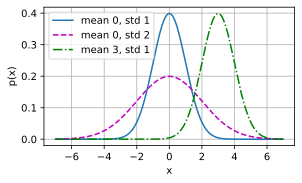

In [12]:
# 再次使用numpy进行可视化
x = np.arange(-7, 7, 0.01)
# 均值和标准差对
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
         ylabel='p(x)', figsize=(4.5, 2.5),
         legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])